<a href="https://colab.research.google.com/github/sahanyafernando/EN3150-A03-edge-cnn/blob/Rajitha/notebooks/01_model_a_standard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Model A Standard CNN

**EN3150 Assignment 03 — Resource-Constrained CNN for Edge Image Classification**  
**Owner:** Rajitha  
**Environment:** Google Colab + TensorFlow/Keras

## Goal

Build and train **Model A — a stronger Standard CNN baseline** for the **17-class UCI Jute Pest classification task**.

This notebook now:

- uses the **same Jute Pest dataset and exact split manifest** created by the shared notebook,
- resizes images to **64 × 64 × 3**,
- uses standard `Conv2D + MaxPooling2D` blocks,
- adds **Batch Normalization**, **Dropout**, and several Dense layers to increase model capacity,
- uses training-only image augmentation to improve generalization,
- trains for **30 epochs**,
- keeps Google Drive checkpoints so training can resume after a Colab disconnect,
- evaluates test accuracy, macro precision, macro recall, confusion matrix, parameter count, model size, epoch time, inference time, and approximate MACs,
- exports `model_a.json` to the shared Jute Pest results folder.

> More layers do **not guarantee** higher accuracy. The purpose of this stronger Model A is to provide a higher-capacity standard-CNN baseline whose measured validation/test performance can later be compared with lightweight Model B.

In [1]:
%pip install -q scikit-learn pillow

In [2]:
import os
import gc
import time
import json
import random
import shutil
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ----------------------------------------------------
# GROUP-SHARED SETTINGS
# ----------------------------------------------------
SEED = 42
IMG_SIZE = 64
BATCH_SIZE = 64

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED =", SEED)
print("IMG_SIZE =", IMG_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)

SEED = 42
IMG_SIZE = 64
BATCH_SIZE = 64


In [4]:
from google.colab import drive
drive.mount("/content/drive")

MEMBER = "rajitha"

# Rajitha's private dataset cache + checkpoints
PERSONAL_ROOT = Path(
    f"/content/drive/MyDrive/EN3150_A03_PERSONAL/{MEMBER}"
)

DATA_ROOT = PERSONAL_ROOT / "dataset_cache" / "jute_pest"
ARTIFACT_ROOT = PERSONAL_ROOT / "artifacts" / "jute_pest"
PLOT_ROOT = PERSONAL_ROOT / "plots" / "jute_pest"

for p in [
    DATA_ROOT,
    ARTIFACT_ROOT,
    PLOT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

# Group shared result folder
SHARED_ROOT = Path(
    "/content/drive/MyDrive/EN3150_A03_SHARED"
)

if not SHARED_ROOT.exists():
    raise FileNotFoundError(
        "EN3150_A03_SHARED was not found in My Drive. "
        "Rajitha should add the shared folder as a My Drive shortcut first."
    )

RESULT_ROOT = (
    SHARED_ROOT
    / "shared_results_jute_pest"
)

RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_PATH = (
    RESULT_ROOT
    / "jute_pest_split_manifest.csv"
)

SUMMARY_PATH = (
    RESULT_ROOT
    / "dataset_summary.json"
)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "jute_pest_split_manifest.csv is missing. "
        "Run Sahanya's updated 00_shared_data_and_final_comparison notebook first."
    )

print("Personal root:", PERSONAL_ROOT)
print("Artifact root:", ARTIFACT_ROOT)
print("Shared result root:", RESULT_ROOT)
print("Manifest:", MANIFEST_PATH)

Mounted at /content/drive
Personal root: /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha
Artifact root: /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha/artifacts/jute_pest
Shared result root: /content/drive/MyDrive/EN3150_A03_SHARED/shared_results_jute_pest
Manifest: /content/drive/MyDrive/EN3150_A03_SHARED/shared_results_jute_pest/jute_pest_split_manifest.csv


In [5]:
# ============================================================
# UCI JUTE PEST DATASET — USE THE EXACT GROUP SPLIT
# ============================================================

DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/920/"
    "jute+pest+dataset.zip"
)

ZIP_PATH = DATA_ROOT / "jute_pest_dataset.zip"
EXTRACT_DIR = DATA_ROOT / "extracted"

# ------------------------------------------------------------
# 1. Download the UCI archive once
# ------------------------------------------------------------
if not ZIP_PATH.exists():

    print("Downloading UCI Jute Pest dataset...")

    temp_zip = ZIP_PATH.with_suffix(".part")

    if temp_zip.exists():
        temp_zip.unlink()

    urllib.request.urlretrieve(
        DATASET_URL,
        temp_zip,
    )

    temp_zip.replace(
        ZIP_PATH
    )

    print("Download complete.")

else:

    print(
        "Using cached dataset ZIP:",
        ZIP_PATH
    )


if not zipfile.is_zipfile(
    ZIP_PATH
):
    raise RuntimeError(
        "The cached UCI file is not a valid ZIP."
    )


# ------------------------------------------------------------
# 2. Extract outer ZIP
# ------------------------------------------------------------
EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

outer_marker = (
    EXTRACT_DIR
    / ".outer_extraction_complete"
)

if not outer_marker.exists():

    print("Extracting outer UCI archive...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zf:

        zf.extractall(
            EXTRACT_DIR
        )

    outer_marker.write_text(
        "Outer ZIP extracted",
        encoding="utf-8"
    )

else:

    print("Outer archive already extracted.")


# ------------------------------------------------------------
# 3. Extract nested ZIP files recursively
# ------------------------------------------------------------
def extract_nested_zips(
    root_folder
):

    processed = set()

    while True:

        nested_zips = [
            p
            for p
            in root_folder.rglob("*.zip")
            if str(
                p.resolve()
            ) not in processed
        ]

        if not nested_zips:
            break

        for nested_zip in nested_zips:

            processed.add(
                str(
                    nested_zip.resolve()
                )
            )

            target_folder = (
                nested_zip.parent
                / (
                    nested_zip.stem
                    + "_extracted"
                )
            )

            marker = (
                target_folder
                / ".extraction_complete"
            )

            if marker.exists():
                continue

            print(
                "Extracting nested ZIP:",
                nested_zip.name
            )

            target_folder.mkdir(
                parents=True,
                exist_ok=True
            )

            if not zipfile.is_zipfile(
                nested_zip
            ):
                continue

            with zipfile.ZipFile(
                nested_zip,
                "r"
            ) as zf:

                zf.extractall(
                    target_folder
                )

            marker.write_text(
                "Nested ZIP extracted",
                encoding="utf-8"
            )


extract_nested_zips(
    EXTRACT_DIR
)


# ------------------------------------------------------------
# 4. Load the shared dataset summary and split manifest
# ------------------------------------------------------------
with open(
    SUMMARY_PATH,
    "r"
) as f:

    dataset_summary = json.load(
        f
    )


CLASS_NAMES = dataset_summary[
    "classes"
]

NUM_CLASSES = int(
    dataset_summary[
        "num_classes"
    ]
)

assert NUM_CLASSES == 17


manifest = pd.read_csv(
    MANIFEST_PATH
)

required_columns = {
    "relative_path",
    "label",
    "class_name",
    "split",
}

assert required_columns.issubset(
    manifest.columns
)


# ------------------------------------------------------------
# 5. Rebuild absolute paths on Rajitha's Drive
# ------------------------------------------------------------
def build_split(
    split_name
):

    part = (
        manifest[
            manifest["split"]
            == split_name
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    paths = np.asarray(
        [
            str(
                EXTRACT_DIR
                / rel_path
            )
            for rel_path
            in part[
                "relative_path"
            ].astype(str)
        ],
        dtype=str,
    )

    labels = (
        part["label"]
        .to_numpy(
            dtype=np.int32
        )
    )

    missing = [
        p
        for p in paths
        if not Path(p).exists()
    ]

    if missing:

        print(
            "Example missing path:",
            missing[0]
        )

        raise FileNotFoundError(
            f"{len(missing)} images from the shared manifest "
            "were not found on Rajitha's extracted dataset. "
            "The dataset must be extracted with the same folder structure "
            "as the shared notebook."
        )

    return (
        paths,
        labels
    )


train_paths, train_labels = (
    build_split(
        "train"
    )
)

val_paths, val_labels = (
    build_split(
        "validation"
    )
)

test_paths, test_labels = (
    build_split(
        "test"
    )
)


print(
    "Classes:",
    NUM_CLASSES
)

print(
    "Train:",
    len(train_paths)
)

print(
    "Validation:",
    len(val_paths)
)

print(
    "Test:",
    len(test_paths)
)


# ------------------------------------------------------------
# 6. Build raw TensorFlow datasets
# ------------------------------------------------------------
def decode_image(
    path,
    label
):

    image_bytes = (
        tf.io.read_file(
            path
        )
    )

    image = (
        tf.io.decode_image(
            image_bytes,
            channels=3,
            expand_animations=False,
        )
    )

    image.set_shape(
        [
            None,
            None,
            3
        ]
    )

    return (
        image,
        label
    )


raw_train = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            train_paths,
            train_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=
        tf.data.AUTOTUNE
    )
)

raw_val = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_paths,
            val_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=
        tf.data.AUTOTUNE
    )
)

raw_test = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            test_paths,
            test_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=
        tf.data.AUTOTUNE
    )
)


def count_examples(ds):

    return int(
        tf.data.experimental
        .cardinality(ds)
        .numpy()
    )


print()
print(
    "TensorFlow cardinality"
)

print(
    "Train:",
    count_examples(
        raw_train
    )
)

print(
    "Validation:",
    count_examples(
        raw_val
    )
)

print(
    "Test:",
    count_examples(
        raw_test
    )
)

print()
print(
    "Shared Jute Pest split loaded successfully."
)

Download complete.
Extracting outer UCI archive...
Extracting nested ZIP: Jute_Pest_Dataset.zip
Classes: 17
Train: 5064
Validation: 1085
Test: 1086

TensorFlow cardinality
Train: 5064
Validation: 1085
Test: 1086

Shared Jute Pest split loaded successfully.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(
    image,
    label
):

    image = tf.image.resize(
        image,
        [
            IMG_SIZE,
            IMG_SIZE
        ],
        antialias=True,
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return (
        image,
        label
    )


# Cache first, then shuffle.
train_ds = (
    raw_train
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .shuffle(
        4096,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        AUTOTUNE
    )
)

val_ds = (
    raw_val
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        AUTOTUNE
    )
)

test_ds = (
    raw_test
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        AUTOTUNE
    )
)

print(
    "Train batches:",
    tf.data.experimental
    .cardinality(
        train_ds
    )
    .numpy()
)

print(
    "Validation batches:",
    tf.data.experimental
    .cardinality(
        val_ds
    )
    .numpy()
)

print(
    "Test batches:",
    tf.data.experimental
    .cardinality(
        test_ds
    )
    .numpy()
)

Train batches: 80
Validation batches: 17
Test batches: 17


---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
chore: load shared UCI Jute Pest split for model A
```
File:
```text
notebooks/01_model_a_standard.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

## Model A architecture — Higher-capacity Standard CNN

This remains a **standard CNN** because the feature extractor uses ordinary `Conv2D` layers interleaved with `MaxPooling2D`.

```text
64×64×3
   ↓
Training-only image augmentation
   ↓
Conv 32 → BN → ReLU
Conv 32 → BN → ReLU
MaxPool
   ↓
Conv 64 → BN → ReLU
Conv 64 → BN → ReLU
MaxPool
   ↓
Conv 128 → BN → ReLU
Conv 128 → BN → ReLU
MaxPool
   ↓
Conv 256 → BN → ReLU
MaxPool
   ↓
Flatten
   ↓
Dense 512 → BN → ReLU → Dropout
   ↓
Dense 256 → BN → ReLU → Dropout
   ↓
Dense 128 → BN → ReLU → Dropout
   ↓
Dense 17 logits
```

Why make Model A larger?

- Standard convolutions provide a strong baseline.
- Multiple convolution blocks can learn progressively more complex pest features.
- Several Dense layers increase classifier capacity.
- Batch normalization stabilizes training.
- Dropout and data augmentation reduce overfitting risk.

This architecture has **far more than 100,000 parameters**, which is allowed for Model A.  
The sub-100k restriction applies to **Model B**, not Model A.

A larger network does **not guarantee** higher accuracy; validation and test results will determine whether the added capacity actually helps.

In [7]:
def build_model_a():

    inputs = keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),
        name="image"
    )

    # ----------------------------------------------------
    # Training-only data augmentation
    # ----------------------------------------------------
    x = layers.RandomFlip(
        "horizontal",
        seed=SEED,
        name="aug_flip"
    )(inputs)

    x = layers.RandomRotation(
        0.08,
        seed=SEED,
        name="aug_rotate"
    )(x)

    x = layers.RandomZoom(
        0.10,
        seed=SEED,
        name="aug_zoom"
    )(x)

    x = layers.RandomContrast(
        0.10,
        seed=SEED,
        name="aug_contrast"
    )(x)

    # Normalize pixel range
    x = layers.Rescaling(
        1.0 / 255.0,
        name="rescale"
    )(x)

    # ----------------------------------------------------
    # Block 1
    # ----------------------------------------------------
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False,
        name="conv1_1"
    )(x)

    x = layers.BatchNormalization(
        name="bn1_1"
    )(x)

    x = layers.ReLU(
        name="relu1_1"
    )(x)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False,
        name="conv1_2"
    )(x)

    x = layers.BatchNormalization(
        name="bn1_2"
    )(x)

    x = layers.ReLU(
        name="relu1_2"
    )(x)

    x = layers.MaxPooling2D(
        name="pool1"
    )(x)

    # ----------------------------------------------------
    # Block 2
    # ----------------------------------------------------
    x = layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False,
        name="conv2_1"
    )(x)

    x = layers.BatchNormalization(
        name="bn2_1"
    )(x)

    x = layers.ReLU(
        name="relu2_1"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False,
        name="conv2_2"
    )(x)

    x = layers.BatchNormalization(
        name="bn2_2"
    )(x)

    x = layers.ReLU(
        name="relu2_2"
    )(x)

    x = layers.MaxPooling2D(
        name="pool2"
    )(x)

    # ----------------------------------------------------
    # Block 3
    # ----------------------------------------------------
    x = layers.Conv2D(
        128,
        3,
        padding="same",
        use_bias=False,
        name="conv3_1"
    )(x)

    x = layers.BatchNormalization(
        name="bn3_1"
    )(x)

    x = layers.ReLU(
        name="relu3_1"
    )(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        use_bias=False,
        name="conv3_2"
    )(x)

    x = layers.BatchNormalization(
        name="bn3_2"
    )(x)

    x = layers.ReLU(
        name="relu3_2"
    )(x)

    x = layers.MaxPooling2D(
        name="pool3"
    )(x)

    # ----------------------------------------------------
    # Block 4
    # ----------------------------------------------------
    x = layers.Conv2D(
        256,
        3,
        padding="same",
        use_bias=False,
        name="conv4_1"
    )(x)

    x = layers.BatchNormalization(
        name="bn4_1"
    )(x)

    x = layers.ReLU(
        name="relu4_1"
    )(x)

    x = layers.MaxPooling2D(
        name="pool4"
    )(x)

    # 64 -> 32 -> 16 -> 8 -> 4
    # Feature map here is approximately 4 × 4 × 256.
    x = layers.Flatten(
        name="flatten"
    )(x)

    # ----------------------------------------------------
    # Dense classifier
    # ----------------------------------------------------
    x = layers.Dense(
        512,
        use_bias=False,
        name="dense512"
    )(x)

    x = layers.BatchNormalization(
        name="bn_dense512"
    )(x)

    x = layers.ReLU(
        name="relu_dense512"
    )(x)

    x = layers.Dropout(
        0.50,
        seed=SEED,
        name="dropout512"
    )(x)

    x = layers.Dense(
        256,
        use_bias=False,
        name="dense256"
    )(x)

    x = layers.BatchNormalization(
        name="bn_dense256"
    )(x)

    x = layers.ReLU(
        name="relu_dense256"
    )(x)

    x = layers.Dropout(
        0.40,
        seed=SEED,
        name="dropout256"
    )(x)

    x = layers.Dense(
        128,
        use_bias=False,
        name="dense128"
    )(x)

    x = layers.BatchNormalization(
        name="bn_dense128"
    )(x)

    x = layers.ReLU(
        name="relu_dense128"
    )(x)

    x = layers.Dropout(
        0.30,
        seed=SEED,
        name="dropout128"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        name="logits"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="Model_A_Complex_Standard_CNN"
    )


model_a = build_model_a()

model_a.summary()

print(
    "Total parameters:",
    f"{model_a.count_params():,}"
)

trainable_parameters = int(
    sum(
        np.prod(v.shape)
        for v
        in model_a.trainable_weights
    )
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Model: "Model_A_Complex_Standard_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_flip (RandomFlip)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_rotate (RandomRotation)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_zoom (RandomZoom)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_contrast (RandomContrast)   │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           51

 Total params: 2,851,057 (10.88 MB)

 Trainable params: 2,847,857 (10.86 MB)

 Non-trainable params: 3,200 (12.50 KB)

Total parameters: 2,851,057
Trainable parameters: 2,847,857


In [8]:
def parameter_table(model):

    rows = []

    for layer in model.layers:

        trainable = int(
            sum(
                np.prod(v.shape)
                for v
                in layer.trainable_weights
            )
        )

        total = int(
            layer.count_params()
        )

        if total > 0:

            rows.append({
                "layer": layer.name,
                "type": layer.__class__.__name__,
                "output_shape": str(
                    layer.output.shape
                ),
                "trainable_params": trainable,
                "total_params": total,
            })

    return pd.DataFrame(
        rows
    )


display(
    parameter_table(
        model_a
    )
)

,layer,type,output_shape,trainable_params,total_params
0,conv1_1,Conv2D,"(None, 64, 64, 32)",864,864
1,bn1_1,BatchNormalization,"(None, 64, 64, 32)",64,128
2,conv1_2,Conv2D,"(None, 64, 64, 32)",9216,9216
3,bn1_2,BatchNormalization,"(None, 64, 64, 32)",64,128
4,conv2_1,Conv2D,"(None, 32, 32, 64)",18432,18432
5,bn2_1,BatchNormalization,"(None, 32, 32, 64)",128,256
6,conv2_2,Conv2D,"(None, 32, 32, 64)",36864,36864
7,bn2_2,BatchNormalization,"(None, 32, 32, 64)",128,256
8,conv3_1,Conv2D,"(None, 16, 16, 128)",73728,73728
9,bn3_1,BatchNormalization,"(None, 16, 16, 128)",256,512


In [9]:
def estimate_macs_a(model):

    total = 0

    for layer in model.layers:

        if isinstance(
            layer,
            layers.Conv2D
        ):

            h, w, cout = map(
                int,
                layer.output.shape[1:]
            )

            cin = int(
                layer.input.shape[-1]
            )

            kh, kw = (
                layer.kernel_size
            )

            total += (
                h
                * w
                * cout
                * kh
                * kw
                * cin
            )

        elif isinstance(
            layer,
            layers.Dense
        ):

            total += (
                int(
                    layer.input.shape[-1]
                )
                * int(
                    layer.units
                )
            )

    return int(
        total
    )


MODEL_A_MACS = (
    estimate_macs_a(
        model_a
    )
)

print(
    "Approximate Conv/Dense MACs:",
    f"{MODEL_A_MACS:,}"
)

Approximate Conv/Dense MACs: 175,671,424


---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
feat: implement higher-capacity standard CNN model A
```
File:
```text
notebooks/01_model_a_standard.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

## Train the stronger Standard CNN

In [10]:
LOSS_FN = (
    keras.losses
    .SparseCategoricalCrossentropy(
        from_logits=True
    )
)


class PersistentEpochTimer(
    keras.callbacks.Callback
):

    def __init__(
        self,
        csv_path
    ):

        super().__init__()

        self.csv_path = Path(
            csv_path
        )

        self.csv_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )


    def on_epoch_begin(
        self,
        epoch,
        logs=None
    ):

        self.start = (
            time.perf_counter()
        )


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        seconds = float(
            time.perf_counter()
            - self.start
        )

        row = pd.DataFrame(
            [{
                "epoch": int(epoch),
                "seconds": seconds,
            }]
        )

        row.to_csv(
            self.csv_path,
            mode="a",
            header=not self.csv_path.exists(),
            index=False,
        )


def read_log(
    run_name
):

    path = (
        ARTIFACT_ROOT
        / run_name
        / "training_log.csv"
    )

    if not path.exists():
        return pd.DataFrame()

    data = pd.read_csv(
        path
    )

    if "epoch" in data:

        data = (
            data
            .drop_duplicates(
                subset=["epoch"],
                keep="last"
            )
            .sort_values(
                "epoch"
            )
        )

    return data


def average_epoch_time(
    run_name
):

    path = (
        ARTIFACT_ROOT
        / run_name
        / "epoch_times.csv"
    )

    if not path.exists():
        return np.nan

    data = (
        pd.read_csv(path)
        .drop_duplicates(
            subset=["epoch"],
            keep="last"
        )
    )

    if len(data) == 0:
        return np.nan

    return float(
        data["seconds"].mean()
    )


def fit_resumable(
    model,
    run_name,
    optimizer,
    epochs
):

    run_dir = (
        ARTIFACT_ROOT
        / run_name
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    final_path = (
        run_dir
        / "final.keras"
    )

    best_path = (
        run_dir
        / "best.keras"
    )

    backup_dir = (
        run_dir
        / "backup"
    )

    log_path = (
        run_dir
        / "training_log.csv"
    )

    timing_path = (
        run_dir
        / "epoch_times.csv"
    )

    if final_path.exists():

        print(
            "Completed run found:",
            run_name
        )

        return (
            keras.models
            .load_model(
                final_path
            )
        )


    model.compile(
        optimizer=optimizer,
        loss=LOSS_FN,
        metrics=[
            keras.metrics
            .SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],
    )


    callbacks = [

        keras.callbacks.BackupAndRestore(
            backup_dir=str(
                backup_dir
            ),
            save_freq="epoch",
            delete_checkpoint=False,
        ),

        keras.callbacks.ModelCheckpoint(
            str(
                best_path
            ),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),

        keras.callbacks.CSVLogger(
            str(
                log_path
            ),
            append=True,
        ),

        PersistentEpochTimer(
            timing_path
        ),
    ]


    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )


    model.save(
        final_path
    )

    return model


def reset_run(
    run_name
):

    path = (
        ARTIFACT_ROOT
        / run_name
    )

    if path.exists():

        shutil.rmtree(
            path
        )

        print(
            "Deleted:",
            path
        )


def plot_history(
    run_name,
    prefix
):

    data = read_log(
        run_name
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        data.epoch + 1,
        data.loss,
        label="Train"
    )

    plt.plot(
        data.epoch + 1,
        data.val_loss,
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(prefix + " Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        PLOT_ROOT
        / (
            prefix.lower()
            .replace(" ", "_")
            + "_loss.png"
        ),
        dpi=180,
    )

    plt.show()


    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        data.epoch + 1,
        data.accuracy,
        label="Train"
    )

    plt.plot(
        data.epoch + 1,
        data.val_accuracy,
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(prefix + " Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        PLOT_ROOT
        / (
            prefix.lower()
            .replace(" ", "_")
            + "_accuracy.png"
        ),
        dpi=180,
    )

    plt.show()

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1375 - loss: 2.9192
Epoch 1: val_accuracy improved from None to 0.05991, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha/artifacts/jute_pest/model_a_jute_complex_adam/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha/artifacts/jute_pest/model_a_jute_complex_adam/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step - accuracy: 0.1738 - loss: 2.7254 - val_accuracy: 0.0599 - val_loss: 3.0284 - learning_rate: 0.0010
Epoch 2/30
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2528 - loss: 2.3497
Epoch 2: val_accuracy improved from 0.05991 to 0.06452, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha/artifacts/jute_pest/model_a_jute_complex_adam/best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/rajitha/artifacts/jute_pest/model_a_jute_complex_adam/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - acc

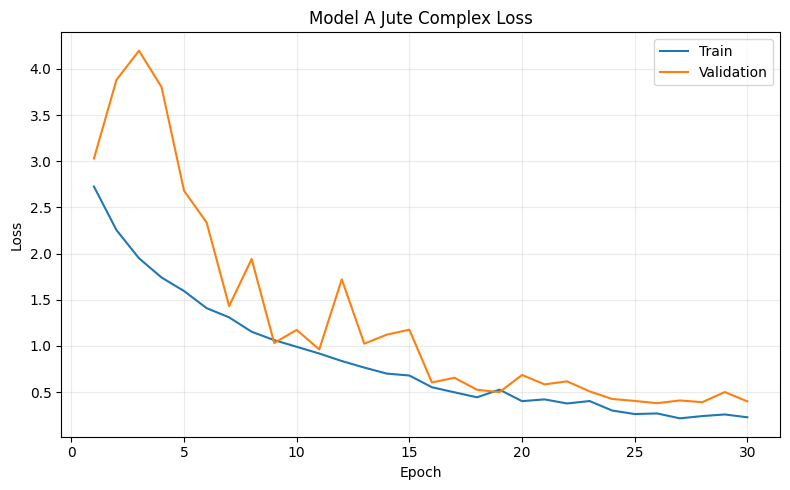

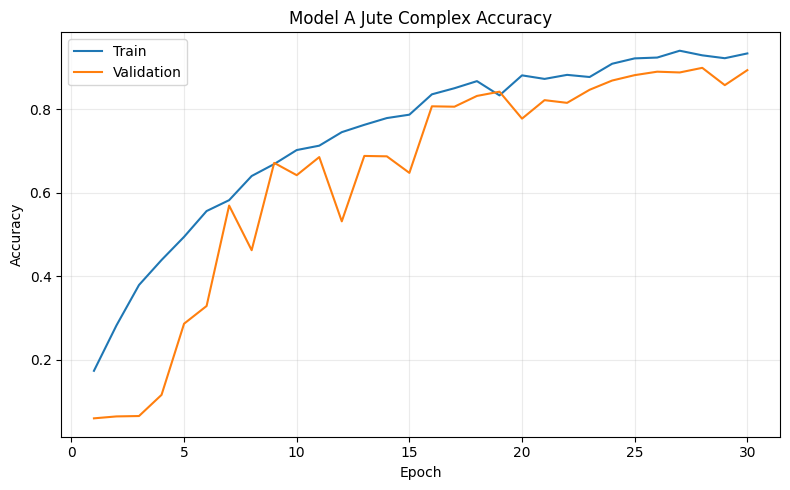

In [11]:
MODEL_A_EPOCHS = 30

RUN_NAME = (
    "model_a_jute_complex_adam"
)

model_a = fit_resumable(
    build_model_a(),
    run_name=RUN_NAME,
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    epochs=MODEL_A_EPOCHS,
)

plot_history(
    RUN_NAME,
    "Model A Jute Complex"
)

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
exp: train complex model A and add learning curves
```
File:
```text
notebooks/01_model_a_standard.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

## Test evaluation

In [ ]:
def get_true_labels(
    ds
):

    return np.concatenate(
        [
            y.numpy()
            for _, y
            in ds
        ]
    )


Y_TEST = get_true_labels(
    test_ds
)


def model_file_size_mb(
    path
):

    return (
        Path(path)
        .stat()
        .st_size
        / (1024 ** 2)
    )


def benchmark_inference_ms_per_image(
    model,
    ds,
    max_batches=10
):

    batches = []
    n_images = 0

    for i, (
        x,
        _
    ) in enumerate(ds):

        if i >= max_batches:
            break

        batches.append(
            x
        )

        n_images += int(
            x.shape[0]
        )


    if not batches:
        return np.nan


    # Warm-up
    _ = model(
        batches[0],
        training=False
    )


    start = (
        time.perf_counter()
    )


    for x in batches:

        _ = model(
            x,
            training=False
        )


    elapsed = (
        time.perf_counter()
        - start
    )


    return (
        elapsed
        * 1000
        / n_images
    )


def evaluate_model(
    model,
    name,
    save_name
):

    logits = model.predict(
        test_ds,
        verbose=0
    )

    predictions = np.argmax(
        logits,
        axis=1
    )


    output = {

        "accuracy": float(
            accuracy_score(
                Y_TEST,
                predictions
            )
        ),

        "precision_macro": float(
            precision_score(
                Y_TEST,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),

        "recall_macro": float(
            recall_score(
                Y_TEST,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
    }


    print(
        json.dumps(
            output,
            indent=2
        )
    )


    print(
        classification_report(
            Y_TEST,
            predictions,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )


    cm = confusion_matrix(
        Y_TEST,
        predictions
    )


    fig, ax = plt.subplots(
        figsize=(14, 12)
    )


    disp = (
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES,
        )
    )


    disp.plot(
        ax=ax,
        xticks_rotation=90,
        colorbar=False,
    )


    ax.set_title(
        name
        + " — Confusion Matrix"
    )


    plt.tight_layout()


    plt.savefig(
        PLOT_ROOT
        / save_name,
        dpi=180,
    )


    plt.show()


    return output

In [ ]:
best_model_path = (
    ARTIFACT_ROOT
    / RUN_NAME
    / "best.keras"
)

best = (
    keras.models
    .load_model(
        best_model_path
    )
)


metrics = evaluate_model(
    best,
    "Model A — Jute Pest",
    "model_a_jute_confusion_matrix.png"
)


log = read_log(
    RUN_NAME
)


result = {

    "dataset": "UCI Jute Pest",

    "num_classes": int(
        NUM_CLASSES
    ),

    "model": (
        "Model A — Complex Standard CNN"
    ),

    "owner": "Rajitha",

    "optimizer": (
        "Adam (initial lr=0.001, "
        "ReduceLROnPlateau)"
    ),

    "epochs": int(
        MODEL_A_EPOCHS
    ),

    "parameters": int(
        best.count_params()
    ),

    "trainable_parameters": int(
        sum(
            np.prod(v.shape)
            for v
            in best.trainable_weights
        )
    ),

    "model_size_mb": float(
        model_file_size_mb(
            ARTIFACT_ROOT
            / RUN_NAME
            / "final.keras"
        )
    ),

    "estimated_fp32_weight_kb": float(
        best.count_params()
        * 4
        / 1024
    ),

    "best_val_accuracy": float(
        log.val_accuracy.max()
    ),

    "accuracy": (
        metrics["accuracy"]
    ),

    "precision_macro": (
        metrics[
            "precision_macro"
        ]
    ),

    "recall_macro": (
        metrics[
            "recall_macro"
        ]
    ),

    "avg_epoch_time_s": float(
        average_epoch_time(
            RUN_NAME
        )
    ),

    "inference_ms_per_image": float(
        benchmark_inference_ms_per_image(
            best,
            test_ds
        )
    ),

    "approx_macs": int(
        MODEL_A_MACS
    ),
}


result_file = (
    RESULT_ROOT
    / "model_a.json"
)


with open(
    result_file,
    "w"
) as f:

    json.dump(
        result,
        f,
        indent=2
    )


print(
    json.dumps(
        result,
        indent=2
    )
)


print(
    "Shared result saved to:",
    result_file
)

## Interpretation

After training, discuss the **measured** results rather than assuming the larger network is better.

Rajitha should comment on:

1. Training vs validation loss across 30 epochs.
2. Training vs validation accuracy and any overfitting.
3. Best validation accuracy.
4. Final test accuracy.
5. Macro precision and macro recall across the 17 pest classes.
6. Which pest classes are confused most often.
7. Total/trainable parameter count.
8. Saved model size.
9. Approximate MAC count.
10. Average epoch time and inference time.
11. Whether the added convolution and Dense capacity actually improved generalization.
12. Why this high-capacity Model A is a useful baseline for the sub-100k Model B.

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
analysis: add Jute Pest model A metrics confusion matrix and result export
```
File:
```text
notebooks/01_model_a_standard.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.